# オートエンコーダ（AE）Sequential API編

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Keras/blob/main/3_Keras_AE_Sequential-API.ipynb)

ここまでのMLP・CNNは「画像 → クラス名」を予測する**教師あり学習**でしたが、オートエンコーダ（AE、Autoencoder）は「画像 → 画像自身」を再現する**教師なし学習**（正解ラベルを使わない学習）です。

## 対象読者・前提知識・動作環境・版とライセンス

- **対象読者**: `1_Keras_MLP.ipynb`で`Dense`層・`compile`・`fit`の基本を学んだ方
- **前提知識**: 「教師あり学習」と「教師なし学習」の違いをこのノートブックで説明するため、事前知識は不要
- **動作環境**: Python 3.10以降、TensorFlow 2.16以降・Keras 3系（`tensorflow.keras`は現在Keras 3を指す）、scikit-learn（PCA用）
- **データセット**: [MNIST](http://yann.lecun.com/exdb/mnist/)（手書き数字0〜9、28×28グレースケール、訓練6万枚・テスト1万枚）
- **版**: 2026-08-03作成

## オートエンコーダとは

オートエンコーダは「入力画像を一度小さな次元（潜在空間）まで圧縮し（エンコーダ）、そこから元の画像を復元する（デコーダ）」ことを学習するニューラルネットワークです。正解ラベルは使わず、「入力画像そのもの」を目標（教師信号）として学習します。うまく圧縮・復元できるようになったモデルの中間表現（潜在空間）は、画像の本質的な特徴を捉えた低次元の表現になっていることが期待されます。

## 目次

1. データの準備
2. モデルの構築
3. 学習
4. 評価（潜在空間・再構成画像）
5. 主成分分析（PCA）との比較

## 教材への接続（Google Colab）

Google Colabで開いた場合は、次のセルを実行してこのリポジトリをクローンし、`module/`（共通ヘルパー関数）や`output/`・`comparison_output/`（他ノートブックとの受け渡しファイル）を含むフォルダへ移動してください。ローカル環境でこのフォルダを直接開いている場合は、次のセルは実行不要です（すでにカレントディレクトリが正しい場所になっています）。


In [ ]:
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Keras.git
%cd Advanced_Tutorial_3_Keras


## 1. データの準備

### ステップ1: ライブラリを読み込み、乱数シードを固定する

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
sys.path.append(str(BASE_DIR))  # module/ はBASE_DIR直下にあるため、BASE_DIR自体をsys.pathに加える

from module.seed_utils import set_seed
from module import data_utils, viz_utils

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

set_seed(42)

### ステップ2: データセットを読み込む（1次元ベクトルに変換）

AEの`Dense`層は1次元ベクトルしか受け取れないため、`data_utils.load_mnist_flat()`は28×28の画像を最初から784次元のベクトルへ変換して返します（`.reshape(-1, 784)`に相当）。

**コラム: このノートブックにラベルのone-hot化がない理由**

底本の教材では、AE（教師なし学習で、ラベルを一切使わない）にもかかわらず「ラベルをone-hotベクトルに変換してから、`argmax`で整数に戻す」という処理が残っていました。one-hot化してすぐ`argmax`で戻すと元の整数ラベルに一致するため、この2手順は実質何もしていないのと同じで、計算の無駄でした。本ノートブックでは、AEが実際に使うのは「散布図の色分け」のための整数ラベルだけなので、`data_utils.load_mnist_flat()`は最初から整数ラベルのみを返す設計にしています。

In [2]:
data = data_utils.load_mnist_flat()

train_images, test_images = data.train_images, data.test_images
train_labels, test_labels = data.train_labels, data.test_labels

train_images.shape, test_images.shape

((60000, 784), (10000, 784))

### ステップ3: 画像を確認する（図1）

C:\Users\japan\AppData\Local\Temp\ipykernel_18920\1689988932.py:9: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_18920\1689988932.py:9: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_18920\1689988932.py:9: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_18920\1689988932.py:9: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_18920\1689988932.py:9: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_18920\1689988932.py:9: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) 

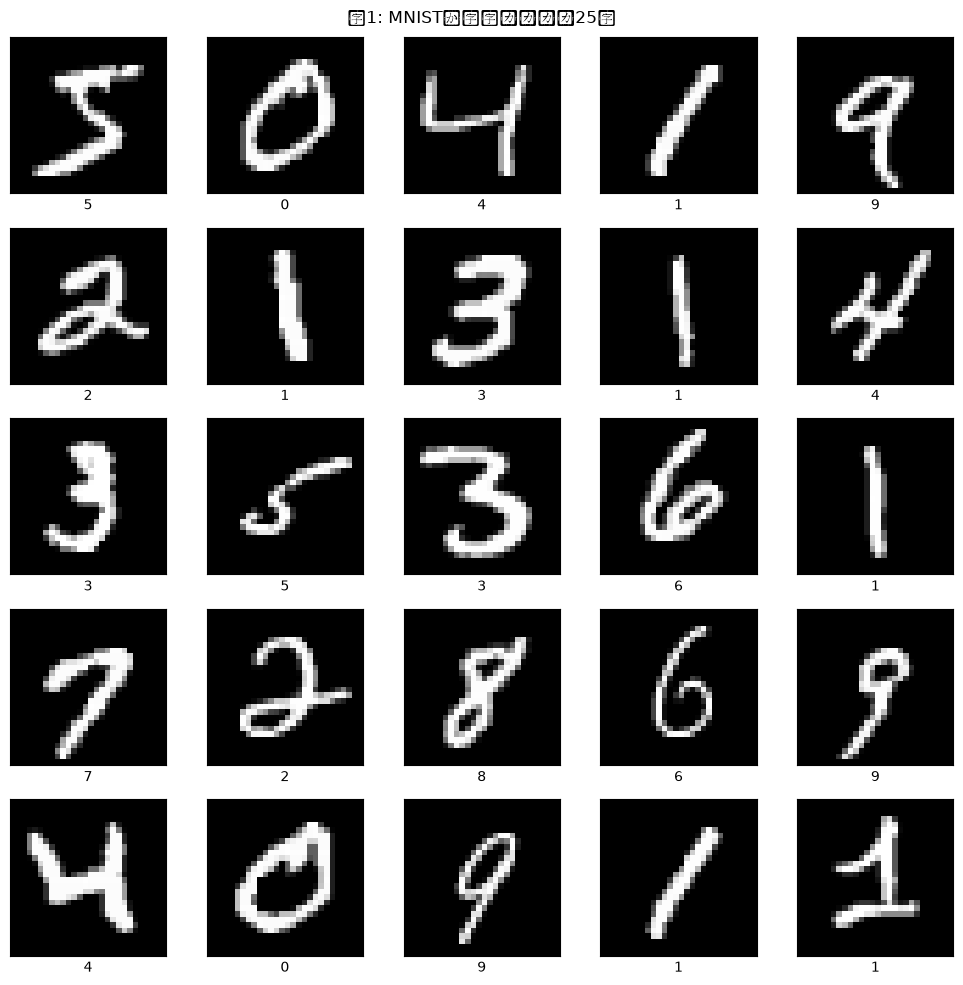

In [3]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i].reshape(28, 28), cmap="gray")
    plt.xlabel(str(train_labels[i]))
plt.suptitle("図1: MNISTの画像サンプル25枚")
plt.tight_layout()
plt.show()

`train_images[i]`は784次元の1次元ベクトルなので、そのままでは`imshow`で画像として表示できません。表示するときだけ`.reshape(28, 28)`で元の2次元の形に戻しています。「モデルに渡すときは1次元、人間が見るときは2次元」という使い分けは、この先何度も登場します。

## 2. モデルの構築

### ステップ1: エンコーダとデコーダを1つの`Sequential`で表す

オートエンコーダは「エンコーダ（圧縮）」と「デコーダ（復元）」の2つの役割を持ちますが、Sequential APIでは1本の層の並びとして書き、どこまでがエンコーダでどこからがデコーダかはコメントで示す構成にします（4節で、エンコーダ部分だけを取り出す方法を扱います）。

入力784次元 → 512 → 128 → **2（潜在空間）** → 128 → 512 → 出力784次元、という左右対称（砂時計型）の構成です。真ん中の2次元が「圧縮された表現」（潜在表現）です。

In [4]:
from tensorflow import keras
from keras.layers import Dense

model = keras.Sequential(name="autoencoder")

# --- エンコーダ: 784次元 → 512 → 128 → 2次元(潜在空間)に圧縮 ---
model.add(keras.Input(shape=(784,)))
model.add(Dense(512, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(2, activation="linear", name="code-layer"))
model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ code-layer (Dense)              │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,842 (1.78 MB)

 Trainable params: 467,842 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

**コラム: `keras.Input`だけでは解決しなかった落とし穴（本ノートブックで実際に踏んだ不具合）**

最初は`Dense(512, activation="relu", input_shape=(784,))`のように、`input_shape`を最初の層へ渡すだけの書き方にしていました。この書き方でも`model.summary()`や`model.fit()`は問題なく動きますが、次のセクションで`model.input`にアクセスして`encoder_seq`を作ろうとした際に、`AttributeError: The layer autoencoder has never been called and thus has no defined input.`というエラーが実際に発生しました。

Kerasの公式ガイドでは、この対策として`keras.Input(shape=...)`を`Sequential`の最初の要素に明示することが推奨されています。実際に上のセルはその書き方に直してありますが、**それでもなお同じエラーが解消しないケースがある**ことが、ユーザーの実行環境（Keras 3系）で確認されました。これはKerasの既知の未解決の不具合で（keras-team/keras#20116、#20339など）、`Sequential`モデルは`.input`/`.output`（および`get_layer(...).output`）へのアクセスが、`keras.Input`を明示していても、バージョンによっては依然として保証されないという、より根が深い問題です。

そのため本ノートブックでは、`model.input`/`.output`に一切頼らない、より頑健な方法でエンコーダを取り出しています（次のセクション参照）。`keras.Input`の明示自体は今後も良い習慣として残していますが、「これさえ書けば`.input`/`.output`は必ず使える」という保証にはなっていない点に注意してください。

潜在空間にあたる`Dense(2, activation="linear", name="code-layer")`だけ、活性化関数が`"linear"`（何もしない、恒等関数）になっている点に注目してください。ここは「2次元に圧縮された数値そのもの」を表現したいので、`relu`のように負の値を0にする活性化関数を使うと表現できる範囲が制限されてしまいます。あとで`name="code-layer"`という名前を使ってこの層を取り出します。


In [5]:
# --- デコーダ: 2次元 → 128 → 512 → 784次元(元の画像サイズ)に復元 ---
model.add(Dense(128, activation="relu"))
model.add(Dense(512, activation="relu"))
model.add(Dense(784, activation="sigmoid"))
model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ code-layer (Dense)              │ (None, 2)              │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 936,466 (3.57 MB)

 Trainable params: 936,466 (3.57 MB)

 Non-trainable params: 0 (0.00 B)

出力層の活性化関数が`"sigmoid"`（出力を0〜1の範囲に収める）になっているのは、入力画像の画素値も0〜1に正規化されているためです。「出力の値域を、正解データの値域に合わせる」のは、オートエンコーダに限らず再構成・回帰系のタスクで意識すべき基本です。

**コラム: 砂時計型（ボトルネック型）アーキテクチャ**

「入力次元 → だんだん小さく → 最も小さいところ（ボトルネック） → だんだん大きく → 出力次元」という形は、オートエンコーダに共通する典型的な構造です。ボトルネック部分の次元数（ここでは2）が小さいほど圧縮率は高くなりますが、復元の精度は下がるというトレードオフがあります。2次元にしているのは、この後の可視化（散布図）でそのままプロットできるようにするためで、精度を優先するなら、もっと大きな次元数（例えば32や64）を選ぶこともあります。

### ステップ2: モデルをコンパイルする

In [6]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
)

分類問題（MLP・CNN）では`categorical_crossentropy`を使いましたが、オートエンコーダは「画像同士の近さ」を測る回帰に近いタスクなので、画素値ごとの二乗誤差の平均である`mean_squared_error`（平均二乗誤差、MSE）を使います。`metrics`を指定していないのは、この損失自体がそのまま再構成の良さを表す指標になるためです。

## 3. 学習

### 学習を実行する: 入力＝正解データ

`model.fit(train_images, train_images, ...)`のように、第1引数（入力）と第2引数（正解ラベルに相当する教師信号）に**同じ`train_images`を渡す**のがオートエンコーダの最大の特徴です。「画像を圧縮して、また同じ画像に復元できるように」学習する、という定義そのままのコードです。

In [7]:
%%time
history = model.fit(
    train_images,
    train_images,
    batch_size=256,
    epochs=30,
    verbose=1,
    validation_data=(test_images, test_images),
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0676 - val_loss: 0.0522
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0497 - val_loss: 0.0475
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0459 - val_loss: 0.0449
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0439 - val_loss: 0.0432
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0423 - val_loss: 0.0419
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0412 - val_loss: 0.0410
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0405 - val_loss: 0.0403
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0398 - val_loss: 0.0399
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0393 - val_loss: 0.0394
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0388 - val_loss: 0.0391
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0384 - val_loss: 0.0388
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 

## 4. 評価（潜在空間・再構成画像）

### ステップ1: 学習曲線を確認する（図2）

c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropb

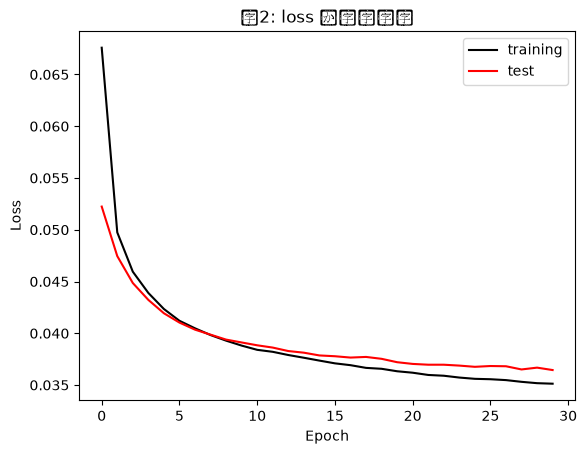

In [8]:
viz_utils.plot_metric_curve(history, metric="loss", fig_num=2, output_dir=OUTPUT_DIR)

### ステップ2: エンコーダ部分だけを取り出す

前のコラムで触れたとおり、`model.input`・`model.get_layer(...).output`を使って新しい`Model`を組み立てる方法は、Keras 3の`Sequential`では`AttributeError`になることがあります。そこで本ノートブックでは、**学習済みの層オブジェクトをそのまま新しい`Sequential`に詰め直す**という、`.input`/`.output`に一切依存しない方法でエンコーダを取り出します。

ポイントは、`model.layers`に入っている各層は「コピー」ではなく学習済みの重みを持つ**同じオブジェクト**だということです。したがって`code-layer`（潜在空間の層）までの層だけを新しい`Sequential`にまとめれば、学習済みの重みを引き継いだまま「入力→潜在表現」だけを行うエンコーダになります。


In [9]:
# code-layer（潜在空間の層）が何番目かを名前で探す
code_layer_index = next(
    i for i, layer in enumerate(model.layers) if layer.name == "code-layer"
)

# 0番目からcode-layerまでの層を、新しいSequentialモデルとして取り出す
# （元のmodelの.input/.outputには一切アクセスしない、より頑健な方法）
encoder_seq = keras.Sequential(model.layers[: code_layer_index + 1])
encoder_seq.build(input_shape=(None, 784))

latent_train_ae_seq = encoder_seq.predict(train_images, verbose=0)
latent_train_ae_seq.shape


(60000, 2)

**コラム: 学習済みモデルから一部分だけを取り出す**

このように「既存のモデルの一部の層までを新しいモデルとして定義し直す」テクニックは、Functional APIの考え方（層は使い回せる、モデルは「入口と出口の指定」にすぎない）があってこそ書けます。`Sequential`で作ったモデルでも`model.input`・`model.get_layer(...).output`はKerasテンソルとして扱えるため、この書き方が可能です。

### ステップ3: 潜在空間を可視化する（図3）

c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\jap

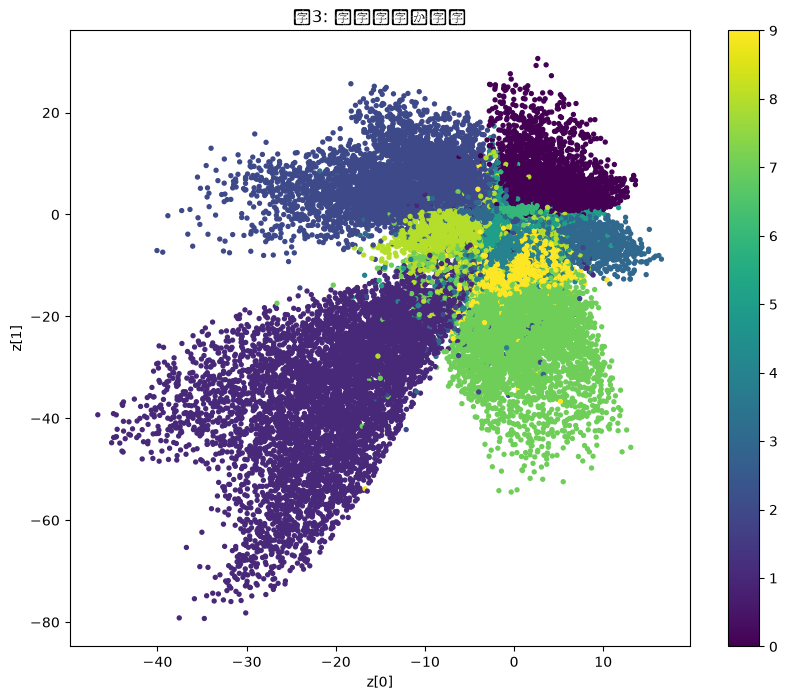

In [10]:
viz_utils.plot_latent_scatter(
    latent_train_ae_seq, train_labels,
    class_names=data_utils.MNIST_CLASS_NAMES, fig_num=3, output_dir=OUTPUT_DIR,
)

同じ数字（同じ色の点）が近くに集まっていれば、「見た目が近い数字は、圧縮した2次元の空間でも近い場所に配置される」というオートエンコーダの狙いどおりの結果です。数字の「4」と「9」、「3」と「8」のように、形が似ている数字同士は潜在空間上でも近く（あるいは重なって）配置される傾向がよく見られます。

### ステップ4: 再構成画像を確認する（図4）

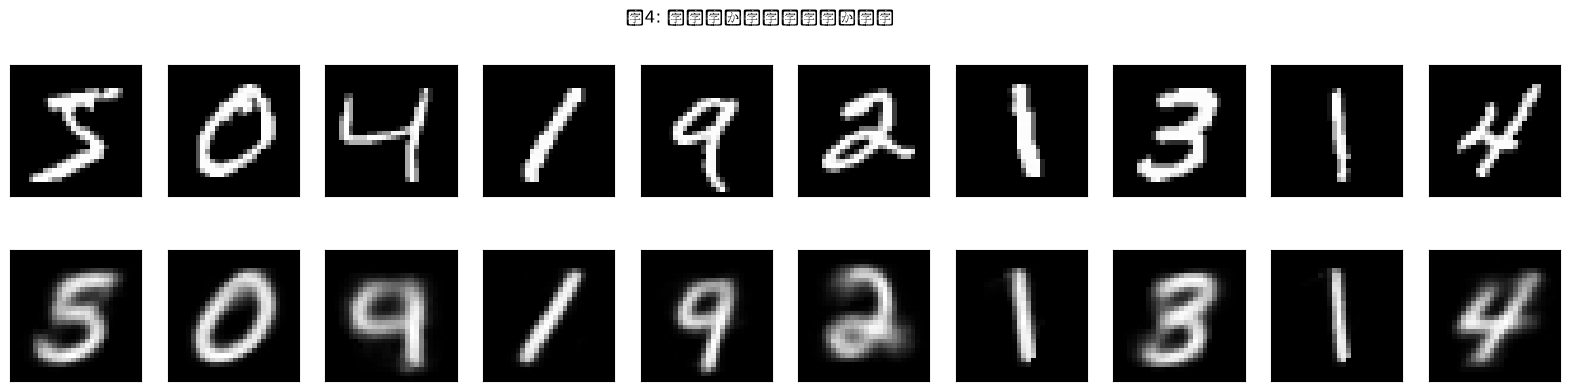

In [12]:
reconstruction_train_ae_seq = model.predict(train_images, verbose=0)

viz_utils.plot_reconstruction_grid(
    train_images, reconstruction_train_ae_seq,
    n=10, image_shape=(28, 28), fig_num=4, output_dir=OUTPUT_DIR,
)

上段が元画像、下段がオートエンコーダによる再構成画像です。784次元の情報を、たった2次元まで圧縮してから復元しているにもかかわらず、数字の大まかな形は再現できていることが確認できます（細部のにじみやぼやけは、圧縮による情報損失です）。

### ステップ5: 学習済みモデルと結果を保存する

In [13]:
train_mse_ae_seq = float(np.mean((train_images - reconstruction_train_ae_seq) ** 2))
print("訓練データに対する再構成MSE:", train_mse_ae_seq)

model.save(OUTPUT_DIR / "ae_seq_trained.keras")
np.savez(
    OUTPUT_DIR / "ae_seq_results.npz",
    latent_train=latent_train_ae_seq,
    reconstruction_train=reconstruction_train_ae_seq,
    train_mse=train_mse_ae_seq,
)
print(f"保存先: {OUTPUT_DIR / 'ae_seq_results.npz'}")

訓練データに対する再構成MSE: 0.03521495684981346
保存先: c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\output\ae_seq_results.npz


`ae_seq_results.npz`は、この後の`3_Keras_AE_Functional-API.ipynb`が結果を比較するために読み込みます。

## 5. 主成分分析（PCA）との比較

オートエンコーダは「非線形な」圧縮・復元を学習するニューラルネットワークです。ここでは対照的に、線形代数にもとづく古典的な次元削減手法「主成分分析（PCA、Principal Component Analysis）」で同じ784→2次元の圧縮を行い、両者を比較します。

### ステップ1: PCAで784次元を2次元に圧縮する

PCAは「データの分散（ばらつき）が最も大きい方向」を順番に見つけ、その方向への射影として低次元表現を作る手法です。オートエンコーダと違い、学習ではなく行列計算（特異値分解）で一意に解が求まります。

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
latent_train_pca = pca.fit_transform(train_images)

latent_train_pca.shape

(60000, 2)

**コラム: PCAにも`random_state`が要る理由**

PCA自体の計算（固有値分解）に乱数は使いませんが、scikit-learnの`PCA`は内部でデータの次元数や件数に応じて計算方法を自動選択し、その一部（`svd_solver="randomized"`が選ばれた場合など）に乱数を使うことがあります。コーディング規約に従い、ここでも念のため`random_state=42`を指定しています。

### ステップ2: PCAの潜在空間を可視化する（図5）

c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\jap

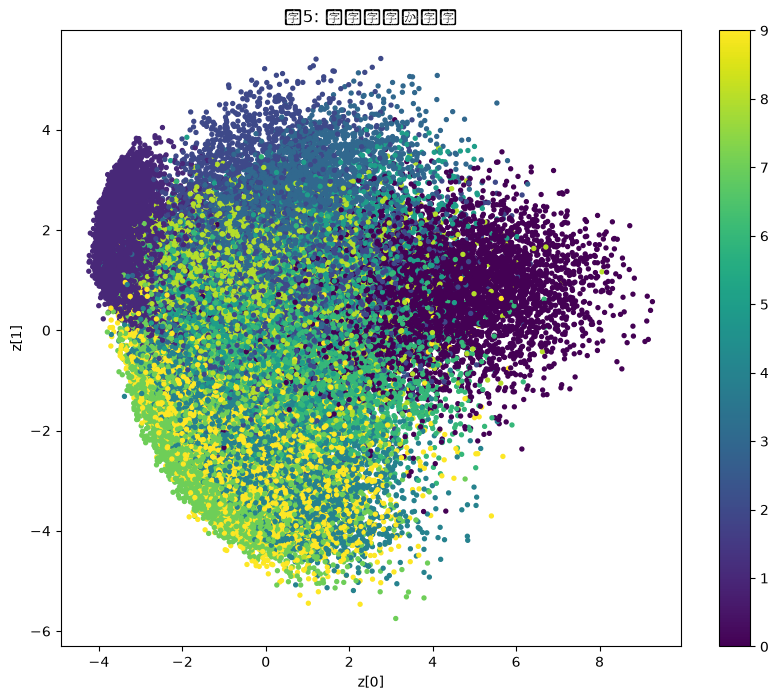

In [15]:
viz_utils.plot_latent_scatter(
    latent_train_pca, train_labels,
    class_names=data_utils.MNIST_CLASS_NAMES, fig_num=5, output_dir=OUTPUT_DIR,
    filename="fig5_latent_scatter_pca.png",
)

### ステップ3: PCAで再構成する（図6）

c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\module\viz_utils.py:26: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.savefig(Path(output_dir) / filename, dpi=150, bbox_inches="tight")
c:\Users\jap

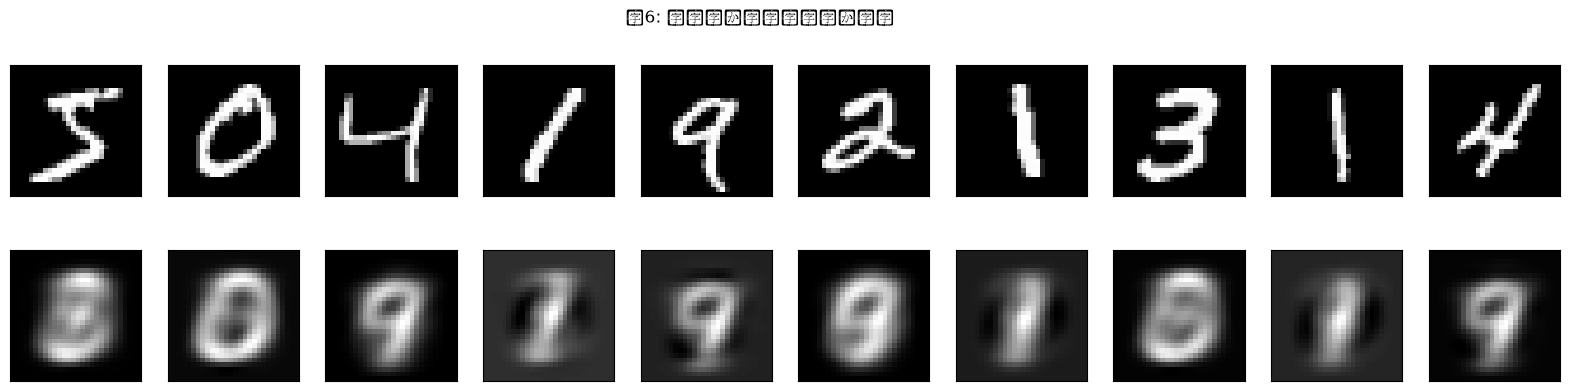

In [16]:
reconstruction_train_pca = pca.inverse_transform(latent_train_pca)

viz_utils.plot_reconstruction_grid(
    train_images, reconstruction_train_pca,
    n=10, image_shape=(28, 28), fig_num=6, output_dir=OUTPUT_DIR,
    filename="fig6_reconstruction_pca.png",
)

`pca.inverse_transform()`は、圧縮した2次元の座標から784次元へ「逆変換」する処理で、オートエンコーダのデコーダに相当します。PCAは直線的な変換しかできないため、AEの再構成と比べるとぼやけ方が大きくなる傾向があります。

### ステップ4: AEとPCAを並べて比較する（図7）

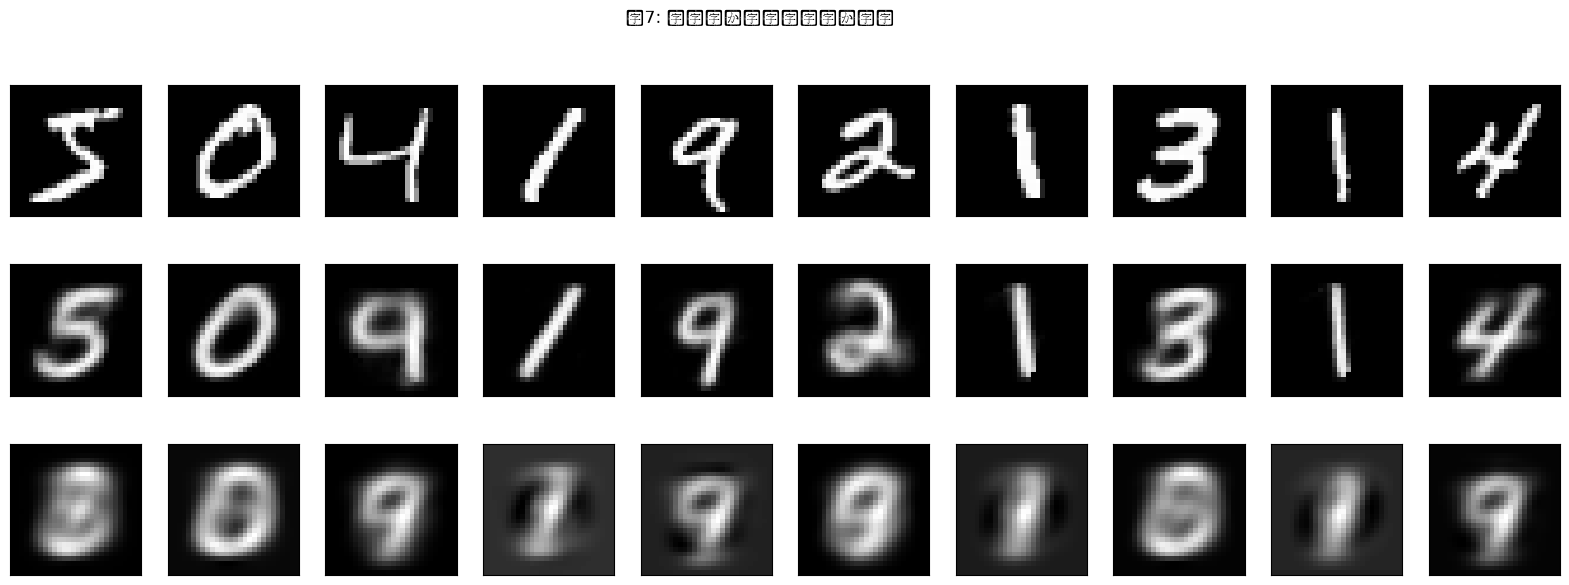

In [17]:
viz_utils.plot_reconstruction_grid(
    train_images,
    {"AE (Sequential)": reconstruction_train_ae_seq, "PCA": reconstruction_train_pca},
    n=10, image_shape=(28, 28), fig_num=7, output_dir=OUTPUT_DIR,
    filename="fig7_reconstruction_ae_vs_pca.png",
)

### ステップ5: 再構成誤差（MSE）を数値で比較し、比較表に記録する

In [18]:
train_mse_pca = float(np.mean((train_images - reconstruction_train_pca) ** 2))

print(f"AE (Sequential) の再構成MSE: {train_mse_ae_seq:.5f}")
print(f"PCA            の再構成MSE: {train_mse_pca:.5f}")

AE (Sequential) の再構成MSE: 0.03521
PCA            の再構成MSE: 0.05595


どちらのMSEが小さいか（＝再構成の誤差が小さいか）は、実行環境や乱数の巡り合わせで多少前後することがありますが、一般には「非線形な変換ができるAE」の方が「直線的な変換しかできないPCA」より同じ次元数でも再構成誤差を小さくできる傾向があります。ただし、AEは学習に時間がかかり、ハイパーパラメータ（層の数・ユニット数・エポック数など）の選び方に結果が左右されるのに対し、PCAは一発で決定的な解が求まるという実用上の利点もあります。

In [19]:
import csv

COMPARISON_DIR = BASE_DIR.parent / "comparison_output"
COMPARISON_DIR.mkdir(exist_ok=True)
comparison_path = COMPARISON_DIR / "reconstruction_comparison.csv"

rows = [
    {"method": "AE", "api_style": "Sequential", "dataset": "MNIST", "latent_dim": 2, "train_mse": train_mse_ae_seq},
    {"method": "PCA", "api_style": "-", "dataset": "MNIST", "latent_dim": 2, "train_mse": train_mse_pca},
]
file_exists = comparison_path.exists()
with open(comparison_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    if not file_exists:
        writer.writeheader()
    writer.writerows(rows)

import pandas as pd
pd.read_csv(comparison_path)

,method,api_style,dataset,latent_dim,train_mse
0,AE,Sequential,MNIST,2,0.035215
1,PCA,-,MNIST,2,0.055953


## まとめ

- MNIST画像（784次元）を2次元に圧縮・復元するオートエンコーダを、Sequential APIの砂時計型（ボトルネック型）構成で組み立てた
- 学習の「正解データ」が入力画像自身であるという、教師なし学習ならではの`fit()`の使い方を確認した
- `name="code-layer"`を手がかりに、学習済みモデルからエンコーダ部分だけを取り出す方法を学んだ
- 古典的な線形手法であるPCAと、再構成画像・潜在空間・再構成誤差(MSE)の3つの観点で比較した

## 本ノートブックで扱っていないこと（今後の課題）

- 潜在空間の次元数（ここでは2）を増やした場合の再構成精度の変化
- ノイズ除去オートエンコーダ（Denoising AE）など、AEの発展形
- 「なめらかに意味が変化する潜在空間」を明示的に学習する変分オートエンコーダ（VAE）。この点は`2_Keras_VAE_Functional-API.ipynb`で扱う
- 本ノートブックと同じ構成をFunctional APIで書き直した内容は、姉妹編`3_Keras_AE_Functional-API.ipynb`を参照

## 演習問題

1. 潜在空間の次元数を2から10に増やしたモデルを作り、再構成MSEがどう改善するか確認しなさい（可視化は`PCA`などでさらに2次元へ落とす必要がある点に注意）。
2. PCAの`n_components`を10、50、100と増やしたときの再構成MSEの変化をグラフにし、「PCAの次元数を増やせばAEに追いつけるか」を考察しなさい。
3. 図7（AE vs PCA）を見比べ、AEの再構成の方が優れている数字・PCAの再構成の方が優れている（あるいは大差ない）数字がないか観察しなさい。